In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

data = pd.read_csv(r'C:\Code_AI\AIO_Code\Module2\LinearRegression\boston_housing.csv')
print(data.isnull().sum())
print(data.info())

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB
None


Epoch 0: Loss = 563.43
Epoch 100: Loss = 32.51
Epoch 200: Loss = 23.04
Epoch 300: Loss = 22.50
Epoch 400: Loss = 22.29
Epoch 500: Loss = 22.16
Epoch 600: Loss = 22.08
Epoch 700: Loss = 22.03
Epoch 800: Loss = 22.00
Epoch 900: Loss = 21.97
---------------------------------
Huấn luyện xong!
Loss cuối cùng (MSE): 21.95
Bias (theta[0]): 22.532806286188695
Các trọng số (weights) còn lại:
 [-0.87243979  0.98514139 -0.0943792   0.71501668 -1.9387766   2.73738792
 -0.02848829 -3.05546651  2.04939371 -1.41239063 -2.02454969  0.85004707
 -3.71538521]


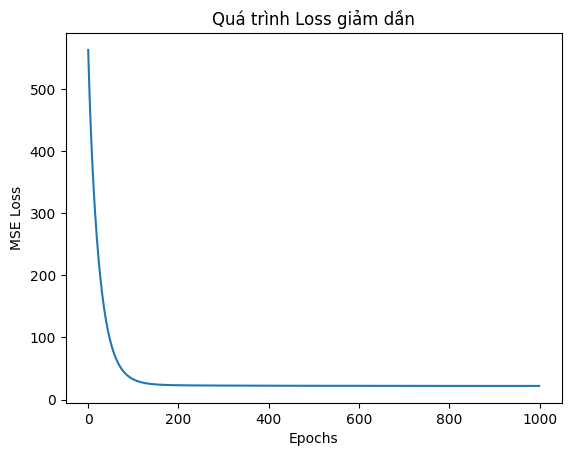

In [15]:
x_data = data.drop(['MEDV'], axis = 1)
y_data = data['MEDV']

X = x_data.values
y = y_data.values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_b = np.c_[np.ones((len(X_scaled), 1)), X_scaled]

def predict(x, theta):
    return x.dot(theta)
def gradient(x, y, theta):
    n = len(y)
    y_hat = predict(x, theta)
    error = y_hat - y
    dtheta = (2 / n) * x.T.dot(error)
    return dtheta
def compute_loss(x, y, theta):
    n = len(y)
    y_hat = predict(x, theta)
    return (1/n) * np.sum((y_hat - y) ** 2)

m, n = X_scaled.shape
theta = np.zeros(n + 1)

learing_rate = 0.01
epochs = 1000
loss_history = []

for i in range(epochs):
    gradients = gradient(X_b, y, theta)
    theta = theta - learing_rate * gradients

    loss = compute_loss(X_b, y, theta)
    loss_history.append(loss)

    if i % 100 == 0:
        print(f"Epoch {i}: Loss = {loss:.2f}")

print("---------------------------------")
print("Huấn luyện xong!")
print(f"Loss cuối cùng (MSE): {loss_history[-1]:.2f}")
print("Bias (theta[0]):", theta[0])
print("Các trọng số (weights) còn lại:\n", theta[1:])

# 6. Vẽ biểu đồ quá trình học (Loss giảm dần theo thời gian)
plt.plot(loss_history)
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Quá trình Loss giảm dần')
plt.show()